In [1]:
import pandas as pd
import numpy as np 

In [2]:
# Create hospital readmission dataset
patients = {
    "Patient_ID": ["P001", "P002", "P003", "P004", "P005",
                   "P006", "P007", "P008", "P009", "P010"],
    "Age": [34, 45, 29, 52, 61, 39, 48, 33, 57, 41],
    "Gender": ["M", "M", "F", "F", "M", "F", "M", None, "M", "F"],
    "Diagnosis": ["Diabetes", "Heart Disease", "Pneumonia", "Diabetes",
                  "Kidney Disease", "Hypertension", "Heart Disease",
                  "Pneumonia", "Diabetes", None],
    "Num_Procedures": [2, 4, 1, 3, 5, 0, 3, 1, 2, 1],
    "Previous_Admissions": [1, 2, 0, 1, 3, 0, 2, 0, 1, 1],
    "Length_of_Stay": [4, 8, 3, 6, 10, 2, 7, 3, 5, 4],
    "Readmitted": ["No", "Yes", "No", "Yes", "Yes",
                   "No", "Yes", "No", "No", "No"]
}

df = pd.DataFrame(patients)

In [3]:
df.to_csv("hospital_readmission_data.csv", index=False)


## PART1 

In [4]:
# 1. Import dataset
df = pd.read_csv("hospital_readmission_data.csv")


In [9]:
# 2. Display first 10 records
print(df.head(10))

  Patient_ID  Age Gender       Diagnosis  Num_Procedures  Previous_Admissions  \
0       P001   34      M        Diabetes               2                    1   
1       P002   45      M   Heart Disease               4                    2   
2       P003   29      F       Pneumonia               1                    0   
3       P004   52      F        Diabetes               3                    1   
4       P005   61      M  Kidney Disease               5                    3   
5       P006   39      F    Hypertension               0                    0   
6       P007   48      M   Heart Disease               3                    2   
7       P008   33    NaN       Pneumonia               1                    0   
8       P009   57      M        Diabetes               2                    1   
9       P010   41      F             NaN               1                    1   

   Length_of_Stay Readmitted  
0               4         No  
1               8        Yes  
2              

In [10]:
# 3. Check shape
print(df.shape)


(10, 8)


In [11]:
# 4. Check data types
print(df.dtypes)


Patient_ID               str
Age                    int64
Gender                   str
Diagnosis                str
Num_Procedures         int64
Previous_Admissions    int64
Length_of_Stay         int64
Readmitted               str
dtype: object


In [12]:
# 5. Identify numerical and categorical variables
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Numerical variables:", numerical_cols)
print("Categorical variables:", categorical_cols)

Numerical variables: ['Age', 'Num_Procedures', 'Previous_Admissions', 'Length_of_Stay']
Categorical variables: ['Patient_ID', 'Gender', 'Diagnosis', 'Readmitted']


C:\Users\1aast\AppData\Local\Temp\ipykernel_22408\2427933934.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [13]:
# 6. Generate descriptive statistics
print(df.describe(include="all"))

       Patient_ID        Age Gender Diagnosis  Num_Procedures  \
count          10  10.000000      9         9       10.000000   
unique         10        NaN      2         5             NaN   
top          P001        NaN      M  Diabetes             NaN   
freq            1        NaN      5         3             NaN   
mean          NaN  43.900000    NaN       NaN        2.200000   
std           NaN  10.640071    NaN       NaN        1.549193   
min           NaN  29.000000    NaN       NaN        0.000000   
25%           NaN  35.250000    NaN       NaN        1.000000   
50%           NaN  43.000000    NaN       NaN        2.000000   
75%           NaN  51.000000    NaN       NaN        3.000000   
max           NaN  61.000000    NaN       NaN        5.000000   

        Previous_Admissions  Length_of_Stay Readmitted  
count             10.000000       10.000000         10  
unique                  NaN             NaN          2  
top                     NaN             NaN     

## Part 2 DATA CLEANING 

In [14]:
# Detect missing values
print(df.isnull().sum())

Patient_ID             0
Age                    0
Gender                 1
Diagnosis              1
Num_Procedures         0
Previous_Admissions    0
Length_of_Stay         0
Readmitted             0
dtype: int64


In [15]:
# Detect duplicates
print(df.duplicated().sum())

0


In [16]:
# Handle missing categorical values
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Diagnosis"] = df["Diagnosis"].fillna(df["Diagnosis"].mode()[0])


In [17]:
# Convert appropriate columns to correct data types
df["Gender"] = df["Gender"].astype("category")
df["Diagnosis"] = df["Diagnosis"].astype("category")
df["Readmitted"] = df["Readmitted"].astype("category")


In [18]:
# Rename columns where required
df = df.rename(columns={
    "Num_Procedures": "Number_of_Procedures",
    "Previous_Admissions": "Prior_Admissions"
})
print(df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'Diagnosis', 'Number_of_Procedures',
       'Prior_Admissions', 'Length_of_Stay', 'Readmitted'],
      dtype='str')


## Part 3 EXPLORATORY DATA ANALYSIS

In [19]:
# 1. Average length of stay
print(df["Length_of_Stay"].mean())

5.2


In [20]:
# 2. Which age group has the highest readmission?
bins = [20, 35, 50, 65]
labels = ["20-35", "36-50", "51-65"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)
print(df[df["Readmitted"] == "Yes"].groupby("Age_Group", observed=True)["Patient_ID"].count())


Age_Group
36-50    2
51-65    2
Name: Patient_ID, dtype: int64


In [21]:
# 3. Which diagnosis has the highest number of patients?
print(df["Diagnosis"].value_counts())


Diagnosis
Diabetes          4
Heart Disease     2
Pneumonia         2
Hypertension      1
Kidney Disease    1
Name: count, dtype: int64


In [22]:
# 4. Percentage of patients readmitted
print(df["Readmitted"].value_counts(normalize=True) * 100)


Readmitted
No     60.0
Yes    40.0
Name: proportion, dtype: float64


In [23]:
# 5. Variables related to readmission
print(df.groupby("Readmitted", observed=True)[["Age", "Number_of_Procedures", "Prior_Admissions", "Length_of_Stay"]].mean())

                  Age  Number_of_Procedures  Prior_Admissions  Length_of_Stay
Readmitted                                                                   
No          38.833333              1.166667               0.5            3.50
Yes         51.500000              3.750000               2.0            7.75


## Part 4 HEALTHCARE VISUALIZATION 

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

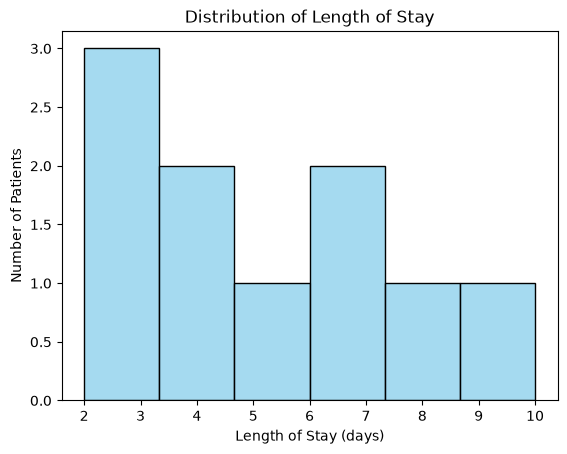

In [25]:
# 1. Length-of-Stay Histogram
sns.histplot(df["Length_of_Stay"], bins=6,color="skyblue")
plt.title("Distribution of Length of Stay")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Number of Patients")
plt.show()

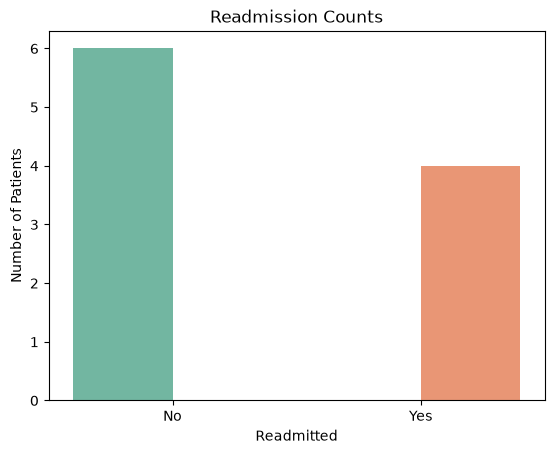

In [28]:
# 2. Readmission Count Plot
sns.countplot(data=df, x="Readmitted", hue="Readmitted", palette="Set2", legend=False)
plt.title("Readmission Counts")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")
plt.show()

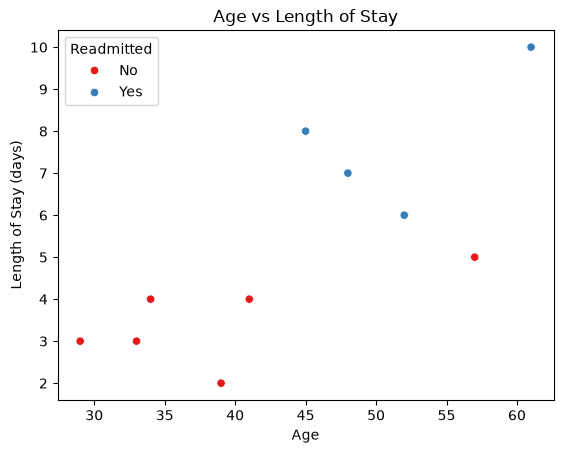

In [29]:
# 3. Age vs Length of Stay
sns.scatterplot(data=df, x="Age", y="Length_of_Stay", hue="Readmitted", palette="Set1")
plt.title("Age vs Length of Stay")
plt.xlabel("Age")
plt.ylabel("Length of Stay (days)")
plt.show()

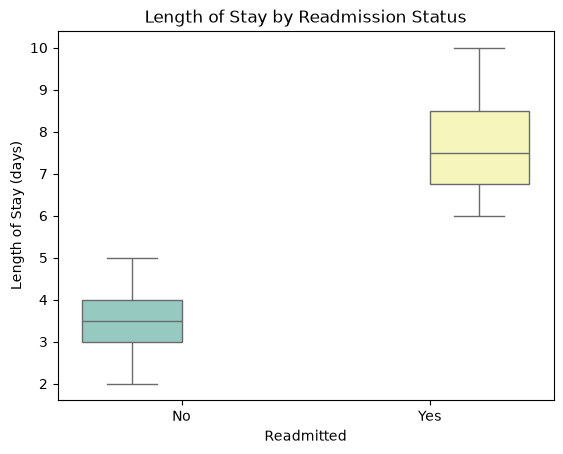

In [30]:
# 4. Boxplot: Length of stay by readmission group
sns.boxplot(data=df, x="Readmitted", y="Length_of_Stay", hue="Readmitted", palette="Set3", legend=False)
plt.title("Length of Stay by Readmission Status")
plt.xlabel("Readmitted")
plt.ylabel("Length of Stay (days)")
plt.show()

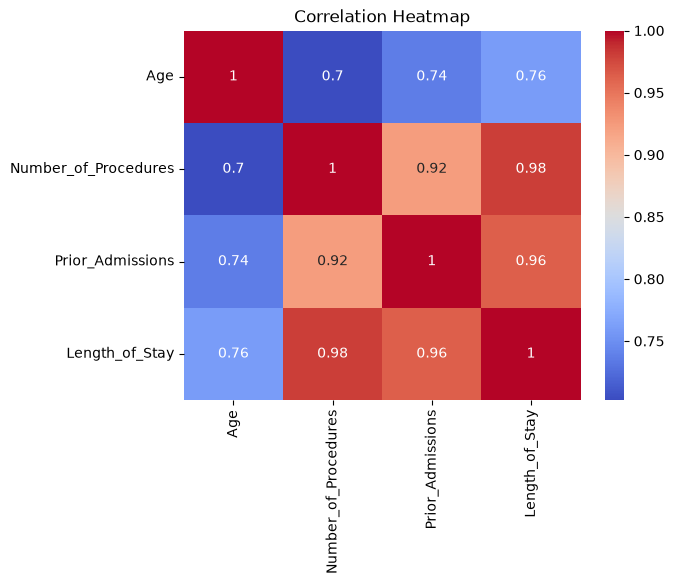

In [31]:
# 5. Correlation Heatmap
corr = df[["Age", "Number_of_Procedures", "Prior_Admissions", "Length_of_Stay"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

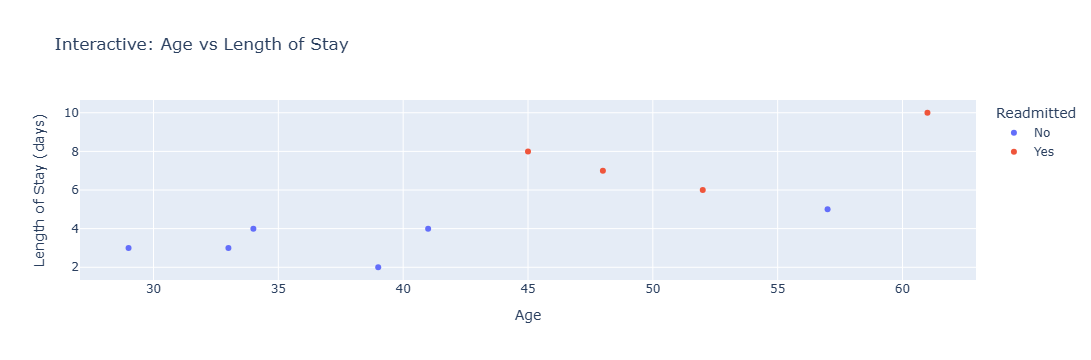

In [32]:
# 6. Interactive Plotly Chart
fig = px.scatter(df, x="Age", y="Length_of_Stay", color="Readmitted",
                  title="Interactive: Age vs Length of Stay")
fig.update_layout(xaxis_title="Age", yaxis_title="Length of Stay (days)")
fig.show()

## Part 5 STATISTICAL TESTING

In [33]:
from scipy import stats

# Independent t-test
group_yes = df[df["Readmitted"] == "Yes"]["Length_of_Stay"]
group_no = df[df["Readmitted"] == "No"]["Length_of_Stay"]
t_stat, p_value = stats.ttest_ind(group_yes, group_no)
print("T-statistic:", t_stat, "P-value:", p_value)



T-statistic: 4.93323850074808 P-value: 0.0011447619704756655


In [34]:
# Chi-Square Test: Gender vs Readmission
contingency_table = pd.crosstab(df["Gender"], df["Readmitted"])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi2:", chi2, "P-value:", p_val)

Chi2: 0.01736111111111114 P-value: 0.8951728848152466


## Part 6 REGRESSION ANALYSIS

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


In [36]:
X = df[["Age", "Number_of_Procedures", "Prior_Admissions"]]
y = df["Length_of_Stay"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

R2 Score: 0.9456643115032278
RMSE: 0.5709764714772693


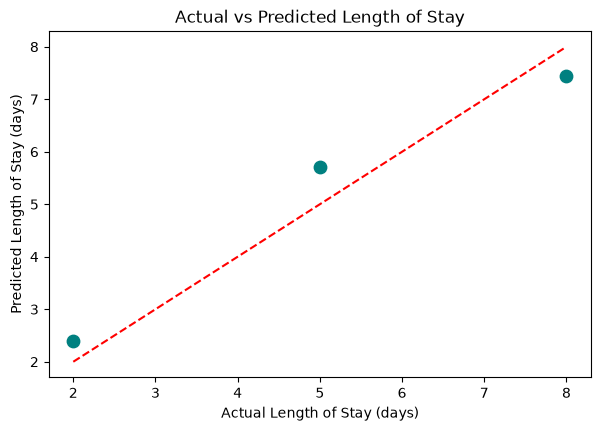

In [38]:
# Actual vs Predicted Length of Stay
plt.figure(figsize=(7, 4.5))
plt.scatter(y_test, y_pred, color="teal", s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--")  # perfect prediction line
plt.title("Actual vs Predicted Length of Stay")
plt.xlabel("Actual Length of Stay (days)")
plt.ylabel("Predicted Length of Stay (days)")
plt.show()

## Part 8 HEALTHCARE INTERPRETATION 

In [20]:


# 1. Which factors appear associated with longer hospital stay?
print("1. Factors associated with longer hospital stay:")
print("   The regression coefficients show Number_of_Procedures and")
print("   Prior_Admissions have the strongest positive effect on")
print("   Length_of_Stay, followed by a smaller effect from Age.")
print("   This is confirmed by the correlation heatmap in Part 4.")



1. Factors associated with longer hospital stay:
   The regression coefficients show Number_of_Procedures and
   Prior_Admissions have the strongest positive effect on
   Length_of_Stay, followed by a smaller effect from Age.
   This is confirmed by the correlation heatmap in Part 4.


In [21]:
# 2. Is readmission statistically associated with any categorical variable?
print("\n2. Association between readmission and categorical variables:")
print("   The Chi-Square test (Gender vs Readmitted) gave a p-value of", p_val)
print("   Since p-value > 0.05, there is no statistically significant")
print("   association between Gender and Readmission in this dataset.")


2. Association between readmission and categorical variables:
   The Chi-Square test (Gender vs Readmitted) gave a p-value of 0.8951728848152466
   Since p-value > 0.05, there is no statistically significant
   association between Gender and Readmission in this dataset.


In [22]:
# 3. How good is the regression model?
print("\n3. Regression model performance:")
print("   R2 Score:", r2_score(y_test, y_pred))
print("   This means the model explains a large portion of the variation")
print("   in Length_of_Stay using Age, Number_of_Procedures, and")
print("   Prior_Admissions. However, with only 10 patients, this result")
print("   should be treated as a demonstration rather than a reliable model.")


3. Regression model performance:
   R2 Score: 0.9456643115032278
   This means the model explains a large portion of the variation
   in Length_of_Stay using Age, Number_of_Procedures, and
   Prior_Admissions. However, with only 10 patients, this result
   should be treated as a demonstration rather than a reliable model.


In [23]:
# 4. What does the R2 score indicate?
print("\n4. Interpretation of R2 score:")
print("   R2 shows the proportion of variation in Length_of_Stay that is")
print("   explained by the predictor variables. An R2 close to 1 means the")
print("   model explains most of the variation; an R2 close to 0 means the")
print("   predictors explain very little of it.")



4. Interpretation of R2 score:
   R2 shows the proportion of variation in Length_of_Stay that is
   explained by the predictor variables. An R2 close to 1 means the
   model explains most of the variation; an R2 close to 0 means the
   predictors explain very little of it.


In [33]:
# 5. What could the hospital do to reduce readmissions?
print("\n5. Recommendations to reduce readmissions:")
print("   - Focus on patients with multiple Prior_Admissions, since the")
print("     grouped averages show they have much higher Length_of_Stay and")
print("     Readmitted rates.")
print("   - Strengthen discharge planning and post-discharge follow-up")
print("     calls for patients undergoing more procedures.")
print("   - Set up targeted care programs for high-frequency diagnosis")
print("     such as Diabetes, which appears most often in this dataset.")


5. Recommendations to reduce readmissions:
   - Focus on patients with multiple Prior_Admissions, since the
     grouped averages show they have much higher Length_of_Stay and
     Readmitted rates.
   - Strengthen discharge planning and post-discharge follow-up
     calls for patients undergoing more procedures.
   - Set up targeted care programs for high-frequency diagnosis
     such as Diabetes, which appears most often in this dataset.
